Do some preliminary analysis on the opinion trend vs. time.

Valid entries: 5740


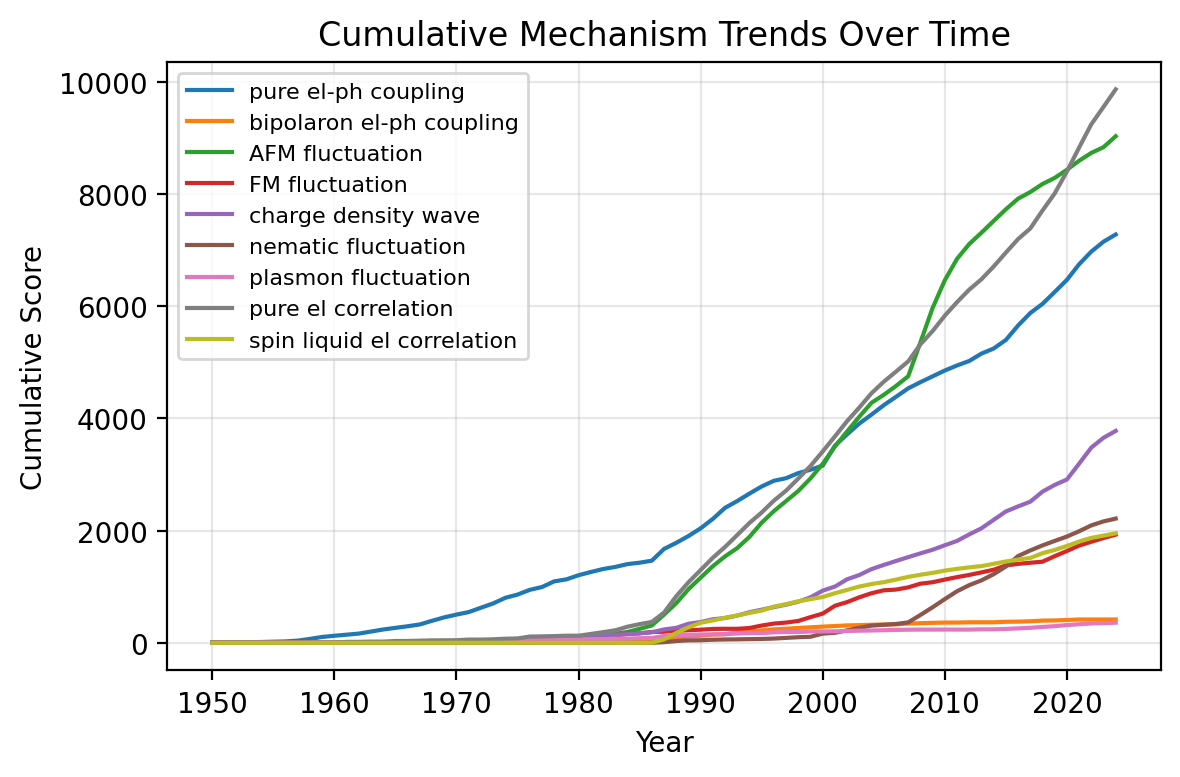

In [1]:
import pandas as pd
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

dat = pd.read_csv('../data/SC_related_cites_010_GPT_processed.csv')

mechanism_keys = [
    'pure el-ph coupling',
    'bipolaron el-ph coupling',
    'AFM fluctuation',
    'FM fluctuation',
    'charge density wave',
    'nematic fluctuation',
    'plasmon fluctuation',
    'pure el correlation',
    'spin liquid el correlation'
]

# ----------------------------------------------------
# 1. Parse dict column and filter valid entries
# ----------------------------------------------------
dat['parsed'] = dat['GPT_output'].apply(eval)

mask = dat['parsed'].apply(
    lambda d: any(d[k] != 0 for k in mechanism_keys)
)
df = dat[mask].copy()

print("Valid entries:", len(df))

# Make sure year is int
df["year"] = df["year"].astype(int)

# ----------------------------------------------------
# 2. Sort by year
# ----------------------------------------------------
df = df.sort_values("year")

# ----------------------------------------------------
# 3. Prepare time axis
# ----------------------------------------------------
YEAR_START = 1950
YEAR_END = df["year"].max()
years = np.arange(YEAR_START, YEAR_END + 1)

# storage: one cumulative array per mechanism
cumulative = {k: np.zeros(len(years), dtype=float) for k in mechanism_keys}

# ----------------------------------------------------
# 4. Accumulate scores by year
# ----------------------------------------------------
for idx, row in df.iterrows():
    y = row["year"]
    d = row["parsed"]

    # index inside years array
    yi = y - YEAR_START

    for k in mechanism_keys:
        cumulative[k][yi] += d[k]

# ----------------------------------------------------
# 5. Convert from "per-year" to "cumulative"
# ----------------------------------------------------
for k in mechanism_keys:
    cumulative[k] = np.cumsum(cumulative[k])

# ----------------------------------------------------
# Now `years` + `cumulative[key]` are ready for plotting
# ----------------------------------------------------

# Example plot: cumulative pure el-ph vs year
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

for k in mechanism_keys:
    plt.plot(years, cumulative[k], label=k)

plt.xlabel("Year")
plt.ylabel("Cumulative Score")
plt.title("Cumulative Mechanism Trends Over Time")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
#plt.yscale('log')
plt.show()


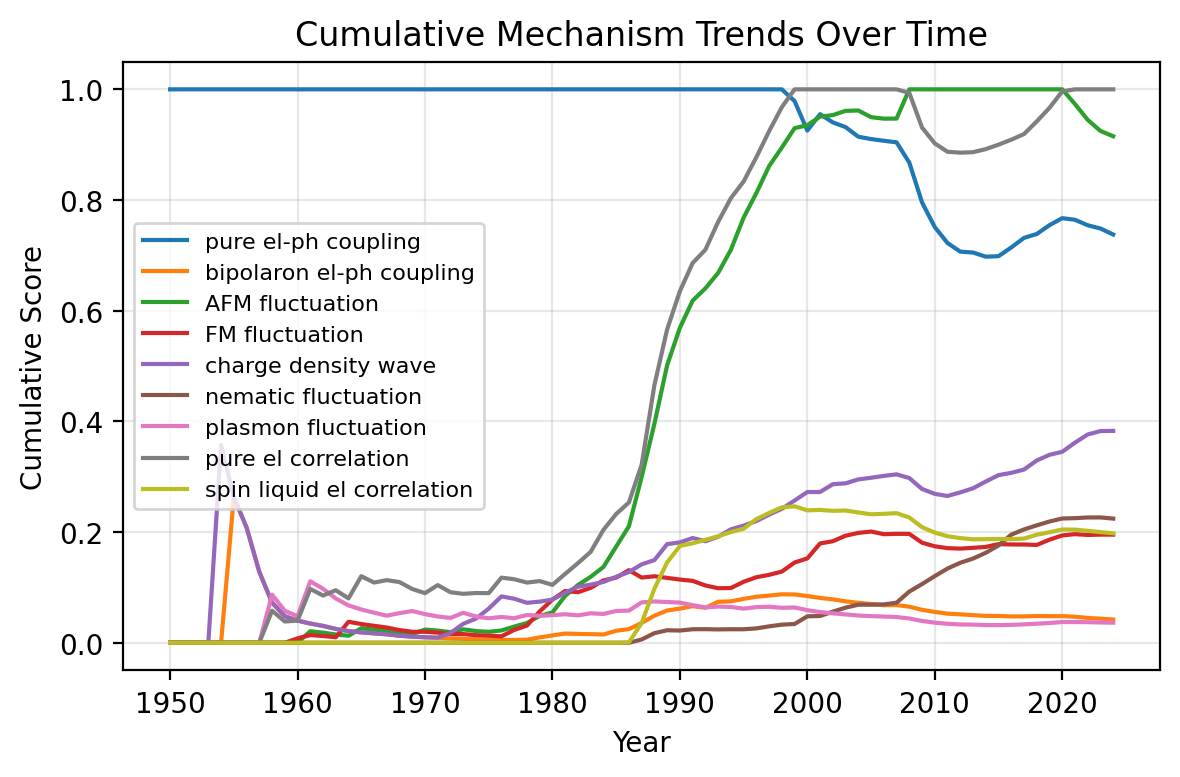

In [2]:
import numpy as np

# shape: (num_mechanisms, T)
stacked = np.vstack([cumulative[k] for k in mechanism_keys])
yearly_max = stacked.max(axis=0)

# avoid divide-by-zero
yearly_max[yearly_max == 0] = 1.0

# normalize
stacked_norm = stacked / yearly_max
for i, k in enumerate(mechanism_keys):
    cumulative[k] = stacked_norm[i]

plt.figure(figsize=(6, 4))

for k in mechanism_keys:
    plt.plot(years, cumulative[k], label=k)

plt.xlabel("Year")
plt.ylabel("Cumulative Score")
plt.title("Cumulative Mechanism Trends Over Time")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
#plt.yscale('log')
plt.show()
